# Data Analysis project
## Spotify songs Dataset

### EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume

## Data loading  
In the following project we will analyse a dataset with several data about some songs listened on Spotify.  
For each song we have the following variables :
- track_id
- track_name
- track_artist
- track_popularity : a grade between 0 and 100
- track_album_id : the id of the album of the track
- track_album_name
- track_album_release_date
- playlist_name
- playlist_genre
- danceability : float between 0 and 1 to quantify if the track is danceable, based on some criterion like tempo, rhythm stability, beat strength, and overall regularity
-  energy : float between 0 and 1 representing a perceptual measure of intensity and activity
-  key : estimated key of the track, 0=C, 1=C#, 2=D ... -1=no key detected
-  loudness : overall loudness in average of a track in decibels (dB), represents the quality of a sound
-  mode : modality of a track : major = 1, minor = 0
-  speechiness : float between 0 and 1 indicating the presence of spoken word in a track >2/3 : almost only spoken words, 1/3< <2/3 : contains both music and speech, <1/3 : music and non-speech-like tracks
-  acousticness : float between 0 and 1 describing if the song is accoustic
-  instrumentalness : float between 0 and 1 representing if the track is more vocal : close to 0 or intrumental : close to 1
-  liveness : float between 0 and 1 detecting the presence or not of an audience. Above 0.8 the track is probably a live
-  valence :  a float between 0 and 1 mesuring the positiveness of a song (close to 1)
-  tempo : tempo in beats per minute (BPM)
-  duration_ms


Possibilités de faires des categories pour key (enfin c'en est deja une), speechiness, liveness, tempo

In [1]:
#pip install prince

In [2]:
#pip install datasets

In [3]:
#pip install yellowbrick

In [4]:
import pandas as pd
import numpy as np
import prince
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import colors

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
# from datasets import load_dataset

In [5]:
song = pd.read_csv("spotify_songs.csv")

In [6]:
song.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


Cleaning data : removing useless columns

In [7]:
song.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [8]:
unique_id = np.unique(song['track_id'])
percentage_duplicate = 100 - round(len(unique_id)/len(song['track_id'])*100,2)
print(f"Percentage of duplicated data: {percentage_duplicate}%")

song.drop_duplicates(subset=['track_id'], inplace = True, ignore_index = True)

Percentage of duplicated data: 13.64%


In [9]:
print(song.iloc[1299])

track_id                                             21jGcNKet2qwijlDFuPiPb
track_name                                                          Circles
track_artist                                                    Post Malone
track_popularity                                                         98
track_album_id                                       4g1ZRSobMefqF6nelkgibi
track_album_name                                       Hollywood's Bleeding
track_album_release_date                                         2019-09-06
playlist_name               Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop
playlist_id                                          46Cl6dmeiylK6TRGXr7hHe
playlist_genre                                                          pop
playlist_subgenre                                             post-teen pop
danceability                                                          0.695
energy                                                                0.762
key         

We delete duplicate tracks using track id to detect them. There are a lot of duplicate data, in fact those correspond to songs that are put in different playlists. Thus we assume that a track only belongs to one playlist.

Track_id, track_name, playlist_id, track_album_id are identifier variables that have no purpose for clustering or inference, thus we will delete them from our dataframe. 

In [10]:
song.drop('track_id', axis = 1, inplace = True)
song.drop('track_name', axis = 1, inplace = True)
song.drop('playlist_id', axis = 1, inplace = True)
song.drop('track_album_id', axis = 1, inplace = True)

Changing release date to only keep the year. Indeed, the exact release date has no purpose for clustering or inference, but we will get more overall information only keeping the year and the month (we will be able to see if one genre of music was trendy for a given year for instance, or if some songs are more popular in summer).

Problem here : time data does not always have the same format : example 2012, 2012-07... We choose to keep everything and set month to 0 if we do not have the info.

In [11]:
from datetime import datetime
#print(song['track_album_release_date'])
years = []
months = []
print(song['track_album_release_date'][1299])
#print(song.size)
for i in range(song.shape[0]):
    #print(song['track_album_release_date'][i])
    #print(i)
    if((len(song['track_album_release_date'][i]))==4):
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y').year)
        months.append(0)
    elif((len(song['track_album_release_date'][i]))==7):
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m').year)
        months.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m').month)
    else:
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m-%d').year)
        months.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m-%d').month)
song['track_album_release_year'] = pd.Series(years)
song['track_album_release_month'] = pd.Series(months)

2019-09-06


Removing track album release date (which is now a bit redundant with the new columns for release year and month)

In [12]:
song.drop('track_album_release_date', axis = 1, inplace = True)

Factoring categorial variables + changing the unit of duration

In [13]:
song['track_artist'] = song['track_artist'].astype('category')
song['track_album_name'] = song['track_album_name'].astype('category')
song['playlist_name'] = song['playlist_name'].astype('category')
song['playlist_genre'] = song['playlist_genre'].astype('category')
song['playlist_subgenre'] = song['playlist_subgenre'].astype('category')
song['mode'] = song['mode'].astype('category')
song['track_album_release_year'] = song['track_album_release_year'].astype('category')
song['track_album_release_month'] = song['track_album_release_month'].astype('category')
song['key'] = song['key'].astype('category')
song['duration_s']=song['duration_ms']/1000
song.drop('duration_ms',axis =1,inplace=True)

Columns containing missing values

In [14]:
print('Columns containing missing values are : ', list(song.columns[song.isnull().sum()!=0]))

Columns containing missing values are :  ['track_artist', 'track_album_name']


Track artist

In [15]:
print("Track artist - Rate of missing values: {:.2f}%".format(song['track_artist'].isnull().sum()/song.shape[0]*100))

Track artist - Rate of missing values: 0.01%


The rate of missing values for track artist variable is really low, it makes no sense to remove the variable nor to set it to the most common track artist, we will thus keep it the way it is.

In [16]:
print("Track album name - Rate of missing values: {:.2f}%".format(song['track_album_name'].isnull().sum()/song.shape[0]*100))

Track album name - Rate of missing values: 0.01%


Same conclusion with track album name than with the track artist variable. So we will delete the rows containing missing values as they will not be able to provide information.

In [17]:
nb_mv_key = 0
for i in range(song.shape[0]):
    if(song['key'][i] == -1):
        nb_mv_key += 1
print("Key - Number of missing values : {:.2f}".format(nb_mv_key))

Key - Number of missing values : 0.00


We basically have no missing values for the $key$ variable, no need to change anything.

We have to be careful because variable $track\_album\_release\_month$ do have missing values, even though those are not
set to null but 0. Thus we still have to check their rate of missing values.

In [18]:
rate_mv_tarm = 0
for i in range(song.shape[0]):
    if(song['track_album_release_month'][i] == 0):
        rate_mv_tarm += (1/song.shape[0])
print("Track album release month - Rate of missing values : {:.2f}%".format(rate_mv_tarm*100))

Track album release month - Rate of missing values : 5.84%


We have a lot of missing values for track album release month. We still have not decided what to do with this.

In [19]:
song.dropna(axis=0, inplace = True)

## Overview on the dataset

In [20]:
song.describe()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
count,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000
mean,39.335320,0.653375,0.698373,-6.817777,0.107939,0.177192,0.091129,0.190955,0.510386,120.958219,226.574631
std,23.699443,0.145791,0.183508,3.036433,0.102547,0.222814,0.232562,0.155888,0.234344,26.954502,61.081364
min,0.000000,0.000000,0.000175,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,21.000000,0.561000,0.579000,-8.310250,0.041000,0.014300,0.000000,0.092600,0.329000,99.972000,187.741250
50%,42.000000,0.670000,0.722000,-6.261000,0.062600,0.079700,0.000021,0.127000,0.512000,121.993500,216.933000
75%,58.000000,0.760000,0.843000,-4.708750,0.133000,0.260000,0.006573,0.249000,0.695000,133.999000,254.975250
max,100.000000,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517.810000


Shorter music : 4s, many zeros values => outliers ?, remove some individuals ?

We have a good representation of each genre (at least 5000 titles), thus it will be interesting to study the genre of a music depending of some other parameters.

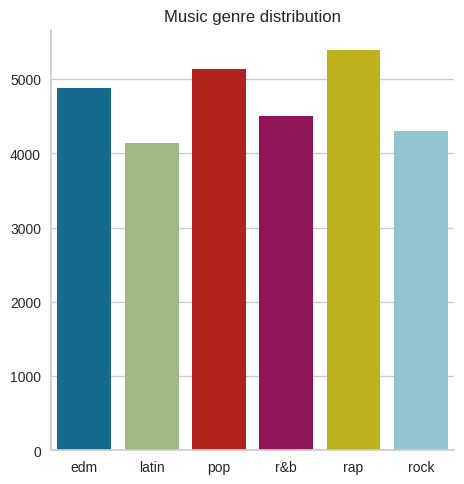

In [21]:
# genre distribution
fig = sns.catplot(data=song, x='playlist_genre', kind='count', hue='playlist_genre')

plt.xlabel('')
plt.ylabel('')
plt.title('Music genre distribution')
plt.show()


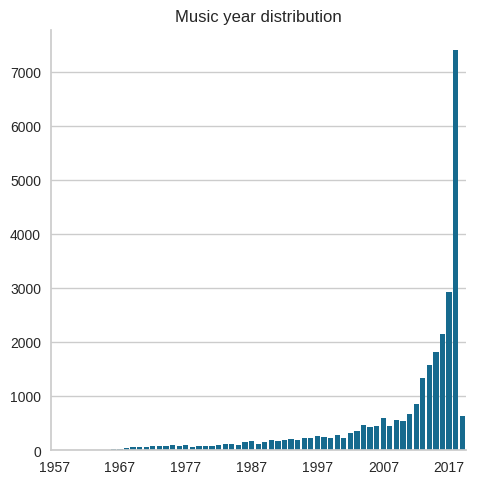

In [22]:
# year of release distribution
fig = sns.catplot(data=song, x='track_album_release_year', kind='count')

plt.xlabel('')
plt.ylabel('')
plt.title('Music year distribution')

xticks = plt.xticks()[0]
plt.xticks(ticks=xticks[::10], labels=[int(t)+min(song['track_album_release_year']) for t in xticks[::10]])
plt.show()

We have more recent musics in the dataset and especialy for 2018 

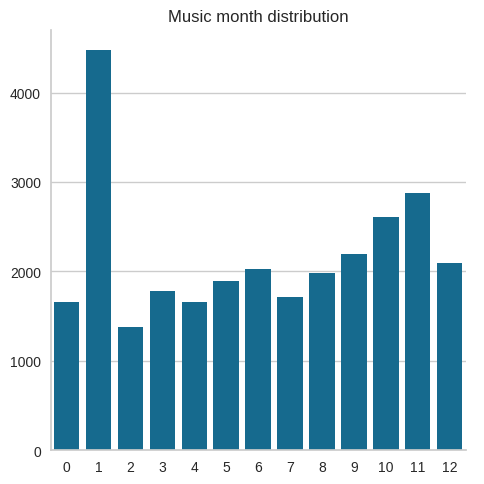

In [23]:
# month of release distribution
fig = sns.catplot(data=song, x='track_album_release_month', kind='count')

plt.xlabel('')
plt.ylabel('')
plt.title('Music month distribution')

xticks = plt.xticks()[0]
plt.xticks(ticks=xticks[::1], labels=[int(t)+min(song['track_album_release_month']) for t in xticks[::1]])
plt.show()

We can see a lot of albums are released in January, this can be explained by the fact that labels produced Christmas songs in Nov/Dec and don't have the time and money for others and also the artists are waiting January not to compete with Christmas songs.
We decide to put the missing monthes to January.

In [24]:
song['track_album_release_month'].replace(0,1,inplace=True)

/tmp/ipykernel_13679/2524397391.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  song['track_album_release_month'].replace(0,1,inplace=True)
/tmp/ipykernel_13679/2524397391.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  song['track_album_release_month'].replace(0,1,inplace=True)


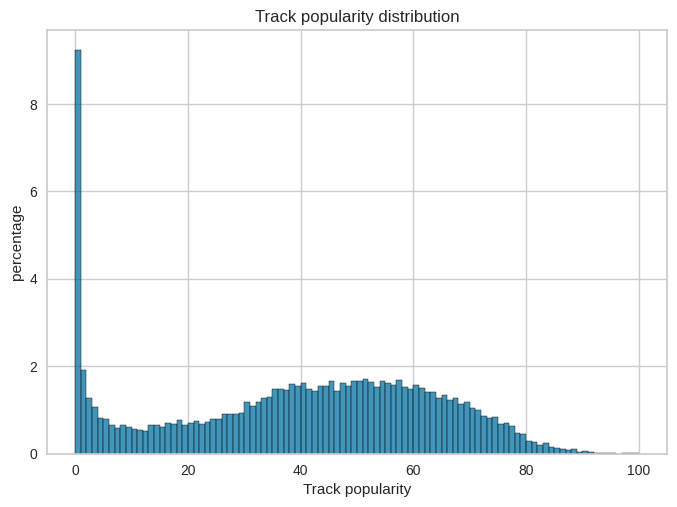

In [25]:
# track popularity distribution
fig=sns.histplot(data=song,x='track_popularity',bins=100,stat='percent')
plt.xlabel('Track popularity')
plt.ylabel('percentage')
plt.title('Track popularity distribution')
plt.show()

We observe a large number of unpopular tracks. This is understandable for new/unknown artists for which the score calculated by Spotify is obviously low even if the music could be good as the score is highly based on the number of streams. After this high number of unpopular tracks between 0 and 5, we can observe a gaussian with mean around 55.

In [26]:
#plt.figure(1)
#mgc=song['playlist_genre'].value_counts(sort=False)
#mg=np.array(song['playlist_genre'].unique()).sort()
#ydc=song['track_album_release_year'].value_counts(sort=True)
#yd=np.array(song['track_album_release_year'].unique()).sort()
#fig, axs = plt.subplots(4, 5, figsize=(20,15))
#axs[0,0].bar(mg,height=mgc)
#axs[0,1].hist(yd)
#plt.show()

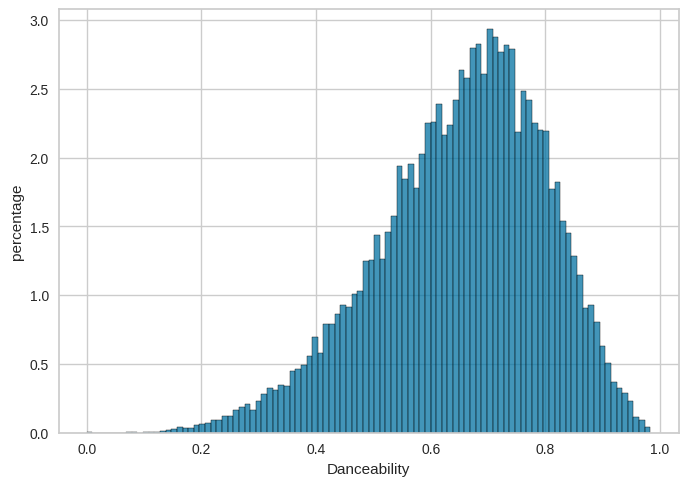

In [27]:
# danceability distribution
fig=sns.histplot(data=song,x='danceability',bins=100,stat='percent')
plt.xlabel('Danceability')
plt.ylabel('percentage')
plt.title('')
plt.show()

We observe a gaussian distribution with a mean around 0.65. We conclude that the majority of the songs are danceable.

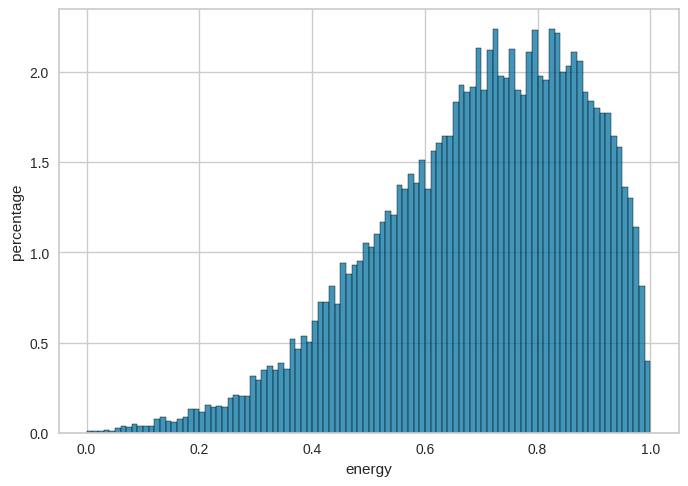

In [28]:
# danceability distribution
fig=sns.histplot(data=song,x='energy',bins=100,stat='percent')
plt.xlabel('energy')
plt.ylabel('percentage')
plt.title('')
plt.show()

Gaussian with high mean => lot of high energy songs

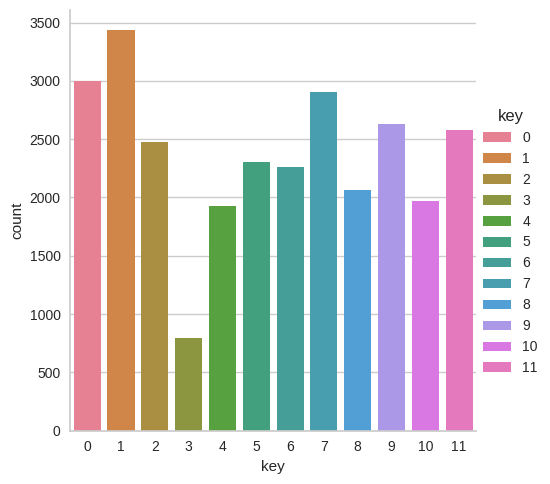

In [29]:
fig=sns.catplot(data=song,x='key',kind='count',hue='key')
plt.xlabel('key')
plt.ylabel('count')
plt.title('')
plt.show()

We observe that there is much less key 3 (D♯/E♭)than the others.

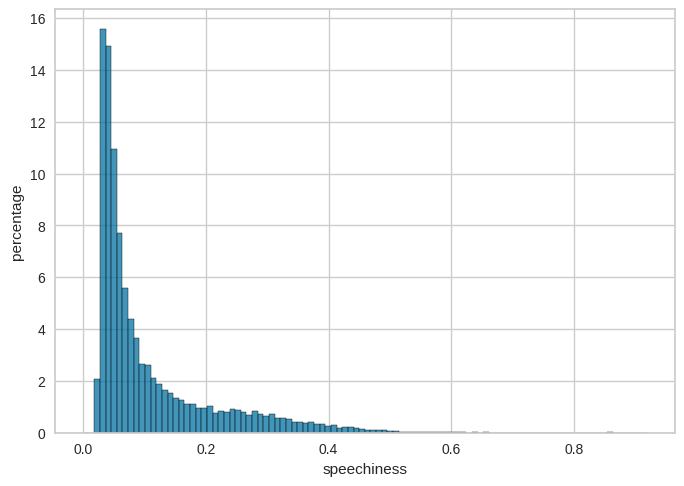

In [30]:
# danceability distribution
fig=sns.histplot(data=song,x='speechiness',bins=100,stat='percent')
plt.xlabel('speechiness')
plt.ylabel('percentage')
plt.title('')
plt.show()

Most songs contains more music than tracks 

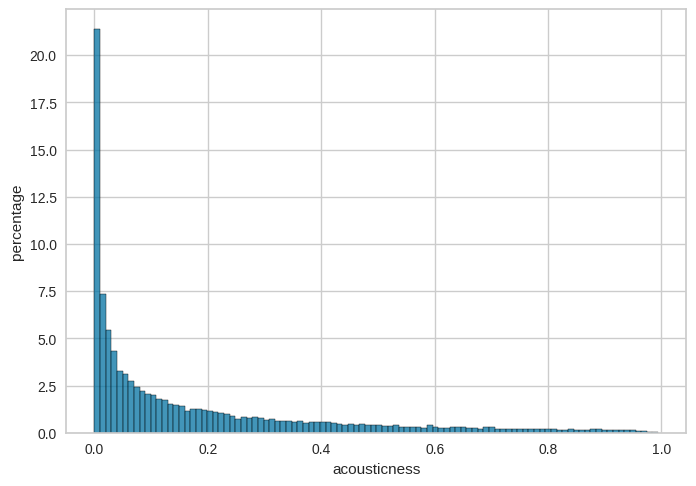

In [31]:
# danceability distribution
fig=sns.histplot(data=song,x='acousticness',bins=100,stat='percent')
plt.xlabel('acousticness')
plt.ylabel('percentage')
plt.title('')
plt.show()

most songs have a low acousticness

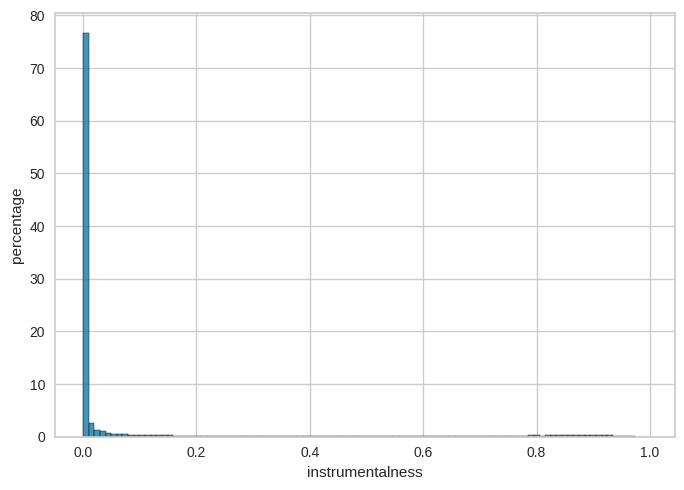

In [32]:
fig=sns.histplot(data=song,x='instrumentalness',bins=100,stat='percent')
plt.xlabel('instrumentalness')
plt.ylabel('percentage')
plt.title('')
plt.show()

most songs are fully vocal (maybe not interesting to analyze)

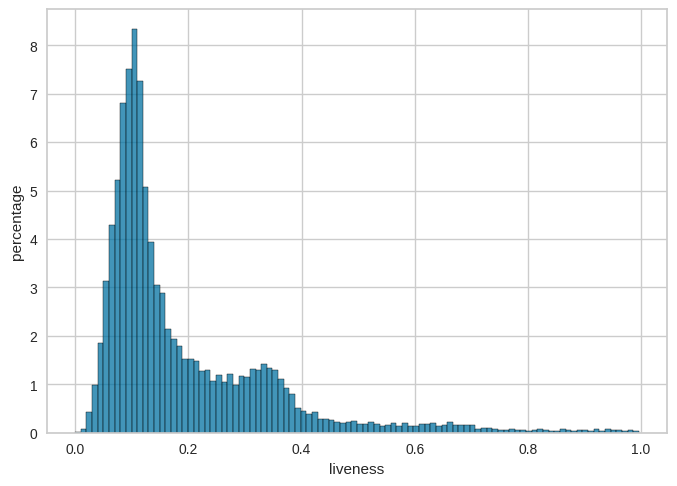

In [33]:
fig=sns.histplot(data=song,x='liveness',bins=100,stat='percent')
plt.xlabel('liveness')
plt.ylabel('percentage')
plt.title('')
plt.show()

most songs are recorded without an audience

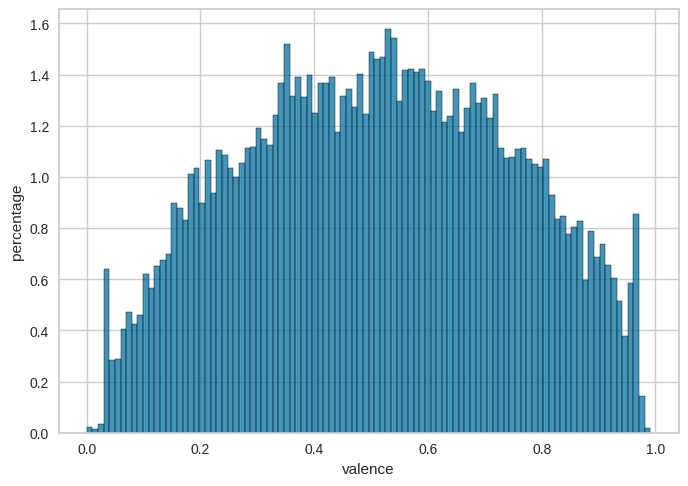

In [34]:
fig=sns.histplot(data=song,x='valence',bins=100,stat='percent')
plt.xlabel('valence')
plt.ylabel('percentage')
plt.title('')
plt.show()

Nice gaussian

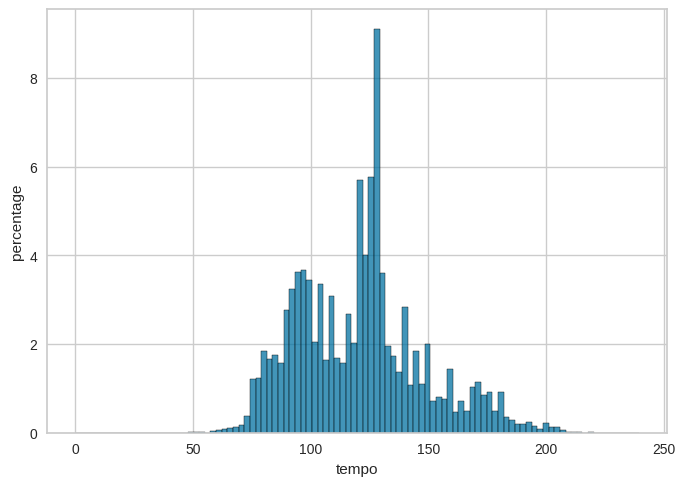

In [35]:
fig=sns.histplot(data=song,x='tempo',bins=100,stat='percent')
plt.xlabel('tempo')
plt.ylabel('percentage')
plt.title('')
plt.show()

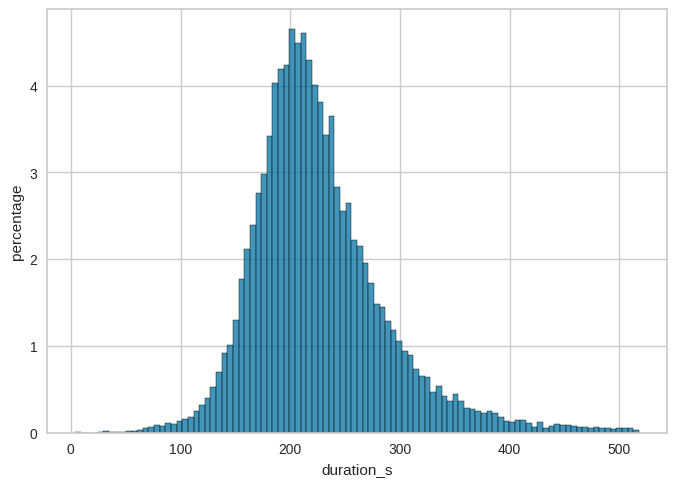

In [36]:
fig=sns.histplot(data=song,x='duration_s',bins=100,stat='percent')
plt.xlabel('duration_s')
plt.ylabel('percentage')
plt.title('')
plt.show()

nice gaussian

### Bidimensionnal analysis

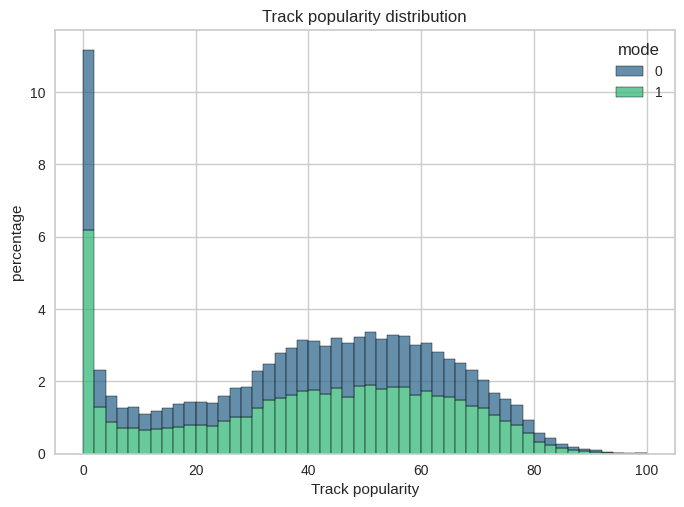

In [37]:
# track popularity distribution
fig=sns.histplot(data=song,x='track_popularity',bins=50,stat='percent', hue='mode', multiple="stack", palette='viridis')
plt.xlabel('Track popularity')
plt.ylabel('percentage')
plt.title('Track popularity distribution')
plt.show()

We can clearly see that the dominant mode is the major one, but follows the distribution of the track popularity, hence it does not seem to affect it.

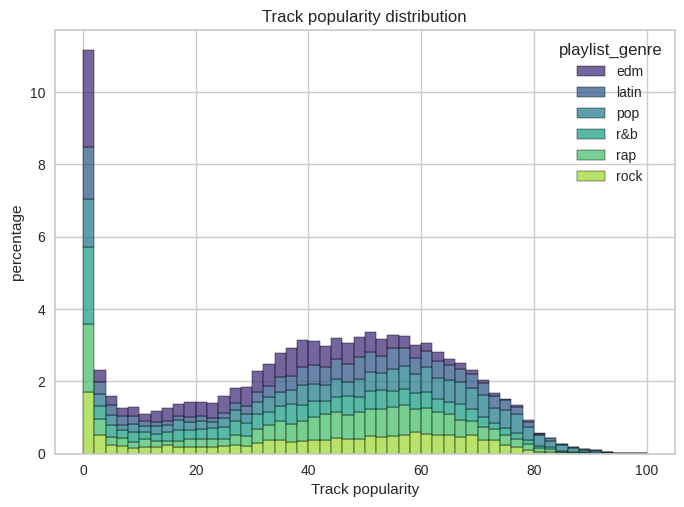

In [38]:
# track popularity distribution
fig=sns.histplot(data=song,x='track_popularity',bins=50,stat='percent', hue='playlist_genre', multiple="stack", palette='viridis')
plt.xlabel('Track popularity')
plt.ylabel('percentage')
plt.title('Track popularity distribution')
plt.show()

We notice that the genre EDM is the most impopular genre, having the most of occurences having 0 popularity score. Moreover, EDM has only a few tracks being popular compared to the other genres. The rap music seems to be most represented at around 50 popularity score, meaning rap musics are often popular, but to a specific part of the population.

## Correlation Plot

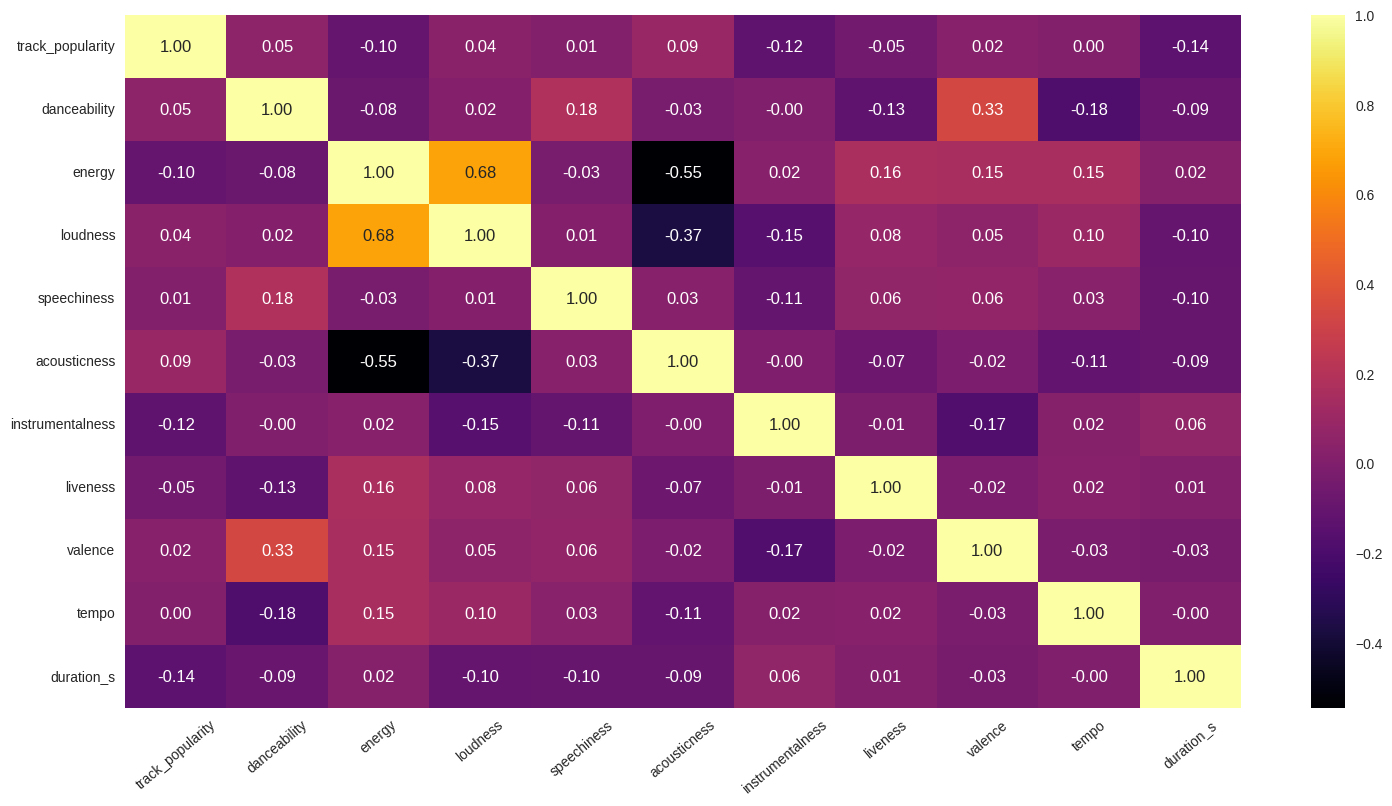

In [39]:
plt.figure(figsize=(18,9))
# correlation between columns
sns.heatmap(song.corr(numeric_only=True), annot=True, fmt='.2f', cmap='inferno')
plt.xticks(rotation=40)

plt.show()

* We observe a strong positive correlation between the variables `energy` and `loudness` which is understandable.
* The other noticeable correlation is a negative one between `energy` and `acousticness`. `acousticness` refers to one's ability to distinguish the different notes, so it makes sense that we have a harder time distinguishing notes when the music is very energetic.

## ACP

In [40]:
song_quanti = song.select_dtypes(include=['float64', 'int64'])

In [41]:
song_quanti.head()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,66,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194.754
1,67,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162.600
2,70,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176.616
3,60,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169.093
4,69,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189.052


In [42]:
#classe pour standardisation
from sklearn.preprocessing import StandardScaler
#instanciation
sc = StandardScaler()
#transformation – centrage-réduction
song_quanti_sc = sc.fit_transform(song_quanti)
#print(song_quanti_sc)

We choose to standardize the dataset as duration and tempo have much higher values compared to energy, acousticness etc.

In [43]:
pca = PCA(n_components=11)
pca.fit(song_quanti_sc)

PCA(n_components=11)

In [44]:
var_exp_ratio = np.cumsum(pca.explained_variance_ratio_)

In [45]:
var_exp_ratio

array([0.1977307 , 0.3410544 , 0.45073983, 0.54694645, 0.63661151,
       0.7241753 , 0.8015172 , 0.87598744, 0.9311176 , 0.97994655,
       1.        ])

We chose to keep 7 dimensions as we can already explain more than 80% of the variance with them. The PCA did not allow us to drastically reduce the number of dimensions, showing us that the variables do not give the same kind of information overall.

In [46]:
pca = PCA(n_components=7)
projected = pca.fit_transform(song_quanti_sc)

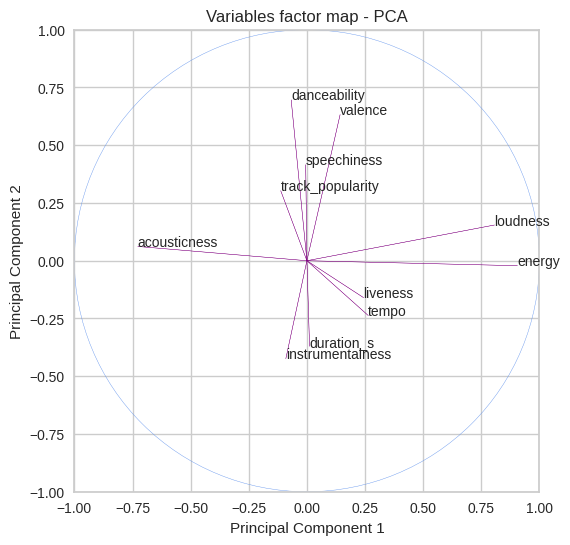

In [47]:
"""
coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])

fig = plt.figure()
for i, j, nom in zip(coord1, coord2, song_quanti.columns):
    plt.text(i, j, nom, fontsize=10)
    plt.arrow(0, 0, i, j, color = 'purple', alpha=0.7, width = 0.0001)

plt.gcf().gca().add_artist(plt.Circle((0, 0), radius = 1, color = 'cornflowerblue', fill = False))

plt.title('Variables factor map - PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.grid(True)
plt.show()
"""

coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1, coord2, song_quanti.columns):
    plt.text(i, j, nom, fontsize=10)
    plt.arrow(0, 0, i, j, color = 'purple', alpha=0.7, width = 0.0001)

plt.axis((-1, 1, -1, 1))
plt.gcf().gca().add_artist(plt.Circle((0, 0), radius = 1, color = 'cornflowerblue', fill = False))

plt.title('Variables factor map - PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.grid(True)
plt.show()

We can make the following assumptions about the first two dimensions :
* Dimension 1: energy of the song
* Dimension 2: whether a song is instrumental or not. Instrumental songs tend to be longer, less danceable and popular compared to popular hits.

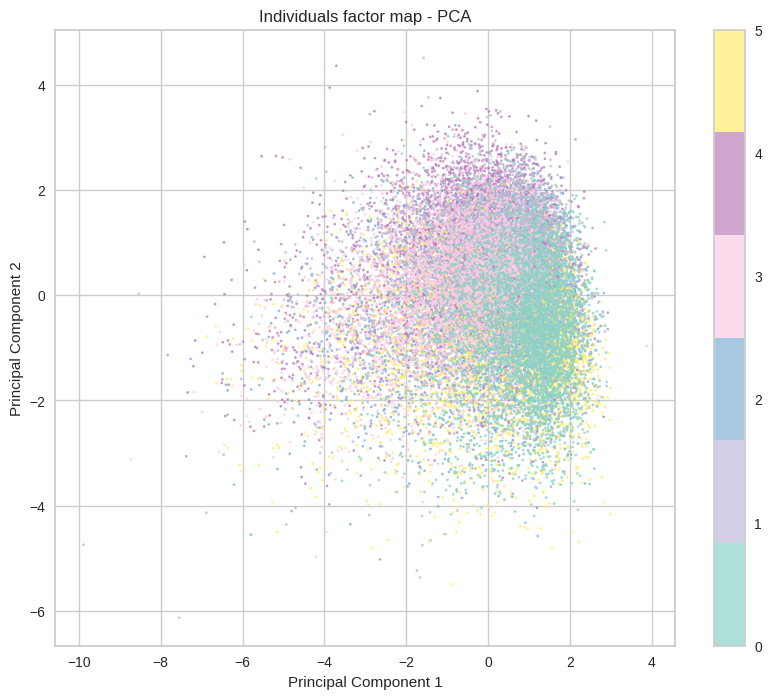

In [48]:
cmap = plt.get_cmap('Set3', 6)
plt.figure(figsize=(10,8))
list_genre = ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']
playlist_genre_num = np.zeros(len(song))

for i in range(len(song)):
        playlist_genre_num[i] = list_genre.index(song.iloc[i]['playlist_genre'])

plt.scatter(projected[:, 0], projected[:, 1], s=1, linewidths=1, alpha=0.7, c=playlist_genre_num, cmap=cmap)
plt.title("Individuals factor map - PCA")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar()
plt.grid(True)
plt.show()

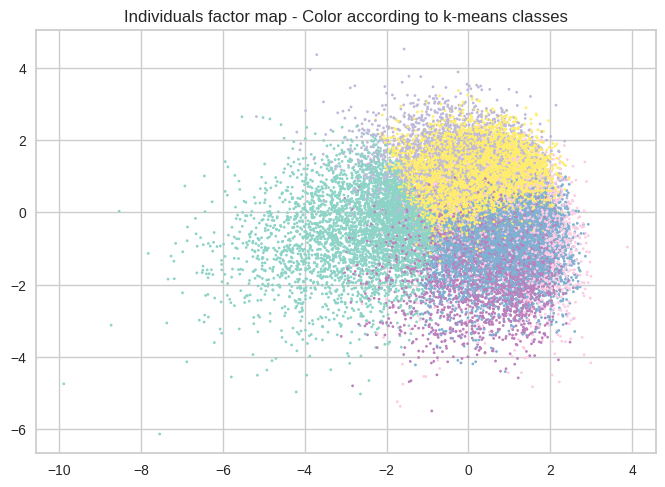

In [49]:
K = 6
kmeans_pca = KMeans(n_clusters=K, init='k-means++', n_init='auto', random_state=0)
clusters_pca = kmeans_pca.fit_predict(projected)

plt.scatter(projected[:,0], projected[:,1], c=clusters_pca, s=1, linewidths=1, cmap=cmap)
plt.title("Individuals factor map - Color according to k-means classes")

plt.grid(True)
plt.show()


Classes size: [1314 2136 1830  568 1303 2226]
Class (in the classif1 numbering): [3 4 5 0 0 1]



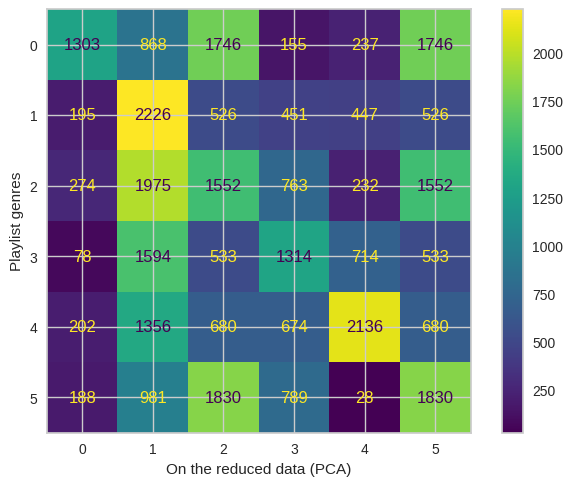

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def matchClasses(classif1, classif2):
    cm = confusion_matrix(classif1, classif2)
    K = cm.shape[0]
    a, b = np.zeros(K), np.zeros(K)
    for j in range(K):
        for i in range(K):
            if (a[j] < cm[i,j]):
                a[j] = cm[i,j]
                b[j] = i 
    a = a.astype(int)
    b = b.astype(int)
                                             
    print ("")
    print ("Classes size:", a)
    print ("Class (in the classif1 numbering):", b)
    print ("")
    
    table = cm.copy()
    for i in range(K):
        table[:,b[i]] = cm[:,i]   
        
    clusters = classif2.copy()
    n = classif2.shape[0]
    for i in range(n):
        for j in range(K):
            if (classif2[i] == j):
                clusters[i] = b[j]
        
    return table, clusters

pgn, clusters_pca_sorted = matchClasses(playlist_genre_num, clusters_pca)

ConfusionMatrixDisplay(pgn).plot()
plt.xlabel('On the reduced data (PCA)')
plt.ylabel('Playlist genres')
plt.show()

When we try to apply K-means to the reduced data from the PCA, using a number of clusters equal to the number of playlist genres, we see with the confusion matrix that the clustering obtained does not correspond to playlist genres as one could expect. In fact, we see that PCA is not that useful, as we did not manage to significantly reduce the number of dimensions on our dataset. We will thus focus on other methods to try to predict the playlist genre using the other quantitative variables of our dataset.

## Linear Discriminant Analysis

In [51]:
song_LDA = song.copy()
song_LDA.drop('track_artist', axis = 1, inplace = True)
song_LDA.drop('track_popularity', axis = 1, inplace = True)
song_LDA.drop('track_album_name', axis = 1, inplace = True)
song_LDA.drop('playlist_name', axis = 1, inplace = True)
song_LDA.drop('track_album_release_year', axis = 1, inplace = True)
song_LDA.drop('track_album_release_month', axis = 1, inplace = True)
song_LDA.drop('playlist_subgenre', axis = 1, inplace = True)
song_LDA.head()

,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194.754
1,pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162.600
2,pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176.616
3,pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169.093
4,pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189.052


We decide to perform a LDA to try to guess the genre using only physical song properties. Thus we drop all other variables.

In [52]:
"""
PG = song_LDA['playlist_genre'].unique()
PG_names = ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']

for i, pg in enumerate(PG):
    data[DPT_names[i]] = 0
    data.loc[data['Department']==dpt, DPT_names[i]] = 1
    data[DPT_names[i]] = data[DPT_names[i]].astype('int')

data = data.drop('Department',axis=1)
# data.head()
"""

"\nPG = song_LDA['playlist_genre'].unique()\nPG_names = ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']\n\nfor i, pg in enumerate(PG):\n    data[DPT_names[i]] = 0\n    data.loc[data['Department']==dpt, DPT_names[i]] = 1\n    data[DPT_names[i]] = data[DPT_names[i]].astype('int')\n\ndata = data.drop('Department',axis=1)\n# data.head()\n"

In [53]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = song_LDA.drop(['playlist_genre'],axis=1)
X = sc.fit_transform(X)

Y = song_LDA['playlist_genre']

train_data, test_data, train_genre, test_genre = train_test_split(X, Y, test_size=0.3, random_state=20)

clf = LinearDiscriminantAnalysis()
clf.fit(train_data, train_genre)

# --- #

pred_genre = clf.predict(test_data)

accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

Accuracy: 46.81 %
 
              precision    recall  f1-score   support

         edm       0.55      0.54      0.55      1413
       latin       0.37      0.32      0.35      1294
         pop       0.34      0.37      0.36      1536
         r&b       0.41      0.36      0.38      1286
         rap       0.54      0.58      0.56      1621
        rock       0.56      0.61      0.59      1356

    accuracy                           0.47      8506
   macro avg       0.46      0.46      0.46      8506
weighted avg       0.47      0.47      0.47      8506



We observe that we do not manage to accurately guess the song genre based on its physical proprties with the LDA. Indeed, in more than half the cases, the LDA fails to predict the genre.

## QDA

In [54]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

X = song_LDA.drop(['playlist_genre'],axis=1)
X = sc.fit_transform(X)
Y = song_LDA['playlist_genre']

clf = QuadraticDiscriminantAnalysis()
clf.fit(train_data, train_genre)

# --- #

pred_genre = clf.predict(test_data)

accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

Accuracy: 48.2 %
 
              precision    recall  f1-score   support

         edm       0.59      0.61      0.60      1413
       latin       0.43      0.23      0.30      1294
         pop       0.34      0.46      0.39      1536
         r&b       0.41      0.44      0.43      1286
         rap       0.57      0.51      0.54      1621
        rock       0.58      0.63      0.60      1356

    accuracy                           0.48      8506
   macro avg       0.49      0.48      0.48      8506
weighted avg       0.49      0.48      0.48      8506



Quadratic Discriminant Analysis does not provide better results.

In [56]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(solver='newton-cholesky')
clf.fit(train_data, train_genre)

# --- #

pred_genre = clf.predict(test_data)

accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

Accuracy: 47.47 %
 
              precision    recall  f1-score   support

         edm       0.54      0.59      0.57      1413
       latin       0.40      0.30      0.34      1294
         pop       0.36      0.34      0.35      1536
         r&b       0.41      0.39      0.40      1286
         rap       0.53      0.57      0.55      1621
        rock       0.56      0.63      0.60      1356

    accuracy                           0.47      8506
   macro avg       0.47      0.47      0.47      8506
weighted avg       0.47      0.47      0.47      8506



## kNN

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
# Optimisation de k
# grille de valeurs
param_grid=[{"n_neighbors":list(range(1,15))}]
knn=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,n_jobs=-1)
knnOpt=knn.fit(train_data, train_genre)  # GridSearchCV est lui même un estimateur
# paramètre optimal
pred_genre = knn.predict(test_data)


accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

knnOpt.best_params_["n_neighbors"]
print("Meilleur score = %f, Meilleur paramètre = %s" % (1.-knnOpt.best_score_,knnOpt.best_params_))

Accuracy: 48.4 %
 
              precision    recall  f1-score   support

         edm       0.54      0.66      0.59      1413
       latin       0.40      0.36      0.38      1294
         pop       0.35      0.37      0.36      1536
         r&b       0.41      0.40      0.40      1286
         rap       0.59      0.55      0.57      1621
        rock       0.62      0.55      0.59      1356

    accuracy                           0.48      8506
   macro avg       0.48      0.48      0.48      8506
weighted avg       0.49      0.48      0.48      8506

Meilleur score = 0.515469, Meilleur paramètre = {'n_neighbors': 14}


> La précision n'est toujours pas très bonne.

## ACP KERNEL

In [85]:
a faire

SyntaxError: invalid syntax (1611439353.py, line 1)

## CA et test du $\chi^2$

In [67]:
song_CA=song[["playlist_genre","track_album_release_year"]].copy()
popularity=[]

for pop in (song["track_popularity"]):
    popularity.append(int(pop/10))
song_CA.insert(1,"popularity_class",popularity)
song_CA["popularity_class"] = song_CA["popularity_class"].astype('category')

song_CA_tab=pd.crosstab(song_CA["popularity_class"], song_CA["playlist_genre"])

In [58]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(song_CA_tab)

print(f"Statistique du Chi-2 : {chi2_stat:.4f}")
print(f"P-value : {p_value:.4f}")
print(f"Degrés de liberté : {dof}")


Statistique du Chi-2 : 2236.8943
P-value : 0.0000
Degrés de liberté : 50


On rejette l'hypothèse d'indépendance, (p-valeur nulle). Il y a donc une dépendance entre le genre de la playlist et sa popularité. 

In [59]:
ca=prince.CA(n_components=2)
ca=ca.fit(song_CA_tab)

In [60]:
ca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.059,74.44%,74.44%
1,0.013,16.56%,91.00%


In [61]:
ca.row_coordinates(song_CA_tab)

,0,1
popularity_class,,
0,-0.168892,-0.016291
1,-0.202022,0.146753
2,-0.299521,0.152209
3,-0.187473,0.056353
4,-0.051965,-0.088360
5,0.096105,-0.114708
6,0.276568,-0.067496
7,0.450443,0.075763
8,0.766927,0.453546


On remarque que plus la musique est populaire, plus elle aura tendance à avoir une grande coordonnée selon chacun des axes.

In [62]:
ca.column_coordinates(song_CA_tab)

,0,1
playlist_genre,,
edm,-0.433084,0.089794
latin,0.085041,-0.107986
pop,0.340576,0.179565
r&b,-0.135379,0.027282
rap,0.079426,-0.123665
rock,0.044969,-0.085518


Selon notre hypothèse que la composante 0 est corrélée à la popularité, la pop est plus populaire que les autres genre et edm est moins populaire.

In [63]:
ca.plot(song_CA_tab)

alt.LayerChart(...)

In [64]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(song_CA_tab)

print(f"Statistique du Chi-2 : {chi2_stat:.4f}")
print(f"P-value : {p_value:.4f}")
print(f"Degrés de liberté : {dof}")

Statistique du Chi-2 : 2236.8943
P-value : 0.0000
Degrés de liberté : 50


In [65]:
ca=prince.CA(n_components=10)
ca=ca.fit(song_CA_tab)

In [66]:
ca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.059,74.44%,74.44%
1,0.013,16.56%,91.00%
2,0.006,7.44%,98.44%
3,0.001,1.15%,99.59%
4,0.000,0.41%,100.00%


In [67]:
ca.row_coordinates(song_CA_tab)

,0,1,2,3,4
popularity_class,,,,,
0,-0.168892,-0.016291,-0.067079,-0.025892,-0.019862
1,-0.202022,0.146753,-0.077786,0.023366,0.033209
2,-0.299521,0.152209,-0.027092,0.038777,-0.023419
3,-0.187473,0.056353,0.057957,-0.018089,0.025159
4,-0.051965,-0.088360,0.114329,-0.017668,-0.003608
5,0.096105,-0.114708,0.028222,0.040563,-0.001986
6,0.276568,-0.067496,-0.084596,0.015461,0.010230
7,0.450443,0.075763,-0.051383,-0.053962,0.000637
8,0.766927,0.453546,0.204029,0.031328,-0.045966


# MCA

On créé une nouvelle variable qualitative sur le tempo pour pouvoir réaliser une MCA en considérant cette variable. On choisit de le découper de la manière suivante   
tempo :

- larghissimo : <40
- largo : 40-60
- adagio : 60-80
- andante : 80-100
- allegretto : 100-120
- vivace : 120-140
- presto : 140-188
- prestissimo : >188

In [68]:
song_MCA=song_CA.copy()
popularity=[]
song_MCA = song_MCA.drop('track_album_release_year', axis=1)
song_MCA = song_MCA.drop('popularity_class', axis=1)

popularity=[]
for pop in (song["track_popularity"]):
    popularity.append(int(pop/25))
tempol = []
for tempo in (song["tempo"]):
    tempol.append(int(tempo/40))

if 'popularity_class' not in song_MCA.columns:
    song_MCA.insert(1,"popularity_class",popularity)
    song_MCA["popularity_class"] = song_MCA["popularity_class"].astype('category')
if 'tempo' not in song_MCA.columns:
    song_MCA.insert(1,"tempo",tempol)
    song_MCA["tempo"] = song_MCA["tempo"].astype('category')
#song_MCA['mode'] = song['mode']
#song_MCA['key'] = song['key']

print(song_MCA)
#song_MCA_tab=pd.crosstab(song_MCA["popularity_class"], song_MCA["playlist_genre"])
#print(song_MCA_tab)

      playlist_genre tempo popularity_class
0                pop     3                2
1                pop     2                2
2                pop     3                2
3                pop     3                2
4                pop     3                2
...              ...   ...              ...
28351            edm     3                1
28352            edm     3                0
28353            edm     3                0
28354            edm     3                0
28355            edm     3                1

[28352 rows x 3 columns]


In [69]:
mca = prince.MCA(
    n_components=10,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mca = mca.fit(song_MCA)
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.477,10.22%,10.22%
1,0.387,8.29%,18.50%
2,0.371,7.94%,26.44%
3,0.362,7.76%,34.20%
4,0.352,7.55%,41.75%
5,0.334,7.15%,48.91%
6,0.333,7.14%,56.05%
7,0.332,7.12%,63.17%
8,0.329,7.05%,70.22%


In [70]:
mca.column_contributions_.style.format('{:.0%}')

,0,1,2,3,4,5,6,7,8,9
playlist_genre__edm,37%,0%,0%,0%,1%,0%,0%,0%,0%,0%
playlist_genre__latin,4%,0%,0%,38%,1%,0%,0%,0%,1%,1%
playlist_genre__pop,1%,28%,9%,4%,0%,0%,0%,1%,1%,0%
playlist_genre__r&b,3%,25%,11%,3%,2%,0%,0%,0%,0%,0%
playlist_genre__rap,2%,0%,13%,5%,20%,0%,0%,0%,0%,19%
playlist_genre__rock,0%,0%,16%,0%,23%,0%,0%,1%,1%,31%
tempo__0,0%,0%,1%,0%,4%,1%,45%,41%,9%,0%
tempo__1,2%,7%,1%,34%,4%,0%,1%,1%,0%,4%
tempo__2,12%,2%,9%,4%,0%,0%,1%,0%,4%,0%
tempo__3,22%,4%,0%,0%,0%,0%,0%,0%,1%,0%


Dimension 1 : genre EDM, tempo entre 80 et 160 BPM

Dimension 2 : genre pop / RnB, popularité entre 60 et 80

Dimension 3 : genres RnB, rap et rock, tempo entre 120 et 160 BPM, popularité entre 40 et 80

Dimension 4 : genre latino, tempo entre 40 et 80 BPM

Dimension 5 : genres rap et rock, popularité entre 0 et 40

...

Remarques globales : 

On constate certaines associations entre genres et tempo caractéristiques. Ainsi le genre EDM est associé à un tempo moyen, le RnB à un tempo plus important et la musique latino à un tempo plus lent et mesuré.

On constate aussi certaines proximités entre genres : les genres Pop et RnB sont assez proches (logique musicalement), le rap et le rock sont aussi assez proches (logique en terme de popularité, ce sont des genres assez populaires). A l'inverse les genres EDM et Latino qui sont assez spéciaux sont plus éloignés.

Les contributions à la sixième dimension, à laquelle contribuent essentiellement les musiques les plus populaires, semble indiquer que ces dernières ont des tempos assez élevés en moyenne.

## Retrouver la décennie d'un titre en fonction de ses caractéristiques physiques : possible?

In [71]:
song_dec = song.copy()
#song_MCA = song_MCA.drop('track_album_release_year', axis=1)
song_dec = song_dec.drop("track_artist", axis = 1)
song_dec = song_dec.drop("track_popularity", axis = 1)
song_dec = song_dec.drop("track_album_name", axis = 1)
song_dec = song_dec.drop("playlist_name", axis = 1)
song_dec = song_dec.drop("track_album_release_month", axis = 1)
song_dec = song_dec.drop("playlist_genre", axis = 1)
song_dec = song_dec.drop("playlist_subgenre", axis = 1)
song_dec['track_album_release_year'] = song_dec['track_album_release_year'].astype('int')
song_dec.info()
song_dec.head()

<class 'pandas.core.frame.DataFrame'>
Index: 28352 entries, 0 to 28355
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   danceability              28352 non-null  float64 
 1   energy                    28352 non-null  float64 
 2   key                       28352 non-null  category
 3   loudness                  28352 non-null  float64 
 4   mode                      28352 non-null  category
 5   speechiness               28352 non-null  float64 
 6   acousticness              28352 non-null  float64 
 7   instrumentalness          28352 non-null  float64 
 8   liveness                  28352 non-null  float64 
 9   valence                   28352 non-null  float64 
 10  tempo                     28352 non-null  float64 
 11  track_album_release_year  28352 non-null  int64   
 12  duration_s                28352 non-null  float64 
dtypes: category(2), float64(10), int64(1)
memory usage:

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_album_release_year,duration_s
0,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,2019,194.754
1,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2019,162.600
2,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,2019,176.616
3,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,2019,169.093
4,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,2019,189.052


Un problème que nous avons est que notre jeu de données n'est pas uniforme en terme d'années représentées. En effet comme vu précédemment les années >= 2010 sont sur-représentées par rapport aux autres. Cela pose problème car le régresseur que l'on va créer risquerait de toujours proposer des années entre 2000 et 2020. Il aurait ainsi de bonnes performances théoriques mais ne serait pas satisfaisant car ne prenant pas vraiment en compte les années 50 à 2000 qui nous intéressent. On va donc se restreindre aux musiques dont l'année de sortie est avant 2000.

In [72]:
song_dec = song_dec[song_dec['track_album_release_year'] <= 2000]
song_dec['key'] = song_dec['key'].astype(int)
song_dec['mode'] = song_dec['mode'].astype(int)
song_dec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4319 entries, 749 to 27949
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   danceability              4319 non-null   float64
 1   energy                    4319 non-null   float64
 2   key                       4319 non-null   int64  
 3   loudness                  4319 non-null   float64
 4   mode                      4319 non-null   int64  
 5   speechiness               4319 non-null   float64
 6   acousticness              4319 non-null   float64
 7   instrumentalness          4319 non-null   float64
 8   liveness                  4319 non-null   float64
 9   valence                   4319 non-null   float64
 10  tempo                     4319 non-null   float64
 11  track_album_release_year  4319 non-null   int64  
 12  duration_s                4319 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 472.4 KB


On opère une analyse multifactorielle sur le jeu de données privé de la variable année de sortie, avec les groupes suivants :
- caractéristiques physiques calculées par Spotify (danceability, speechiness, ...) dont les méthodes de calcul ne sont pas connues
- caractéristiques musicales (variables key et mode)
- durée
- tempo

In [73]:
song_dec_wy = song_dec.drop("track_album_release_year", axis = 1)
dict_indexes = {
    "physical" : ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"],
    "music" : ["key", "mode"],
    "duration" : ["duration_s"],
    "tempo" : ["tempo"]
}
mfa = prince.MFA(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mfa = mfa.fit(
    song_dec_wy, groups = dict_indexes
)

In [74]:
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.159,15.68%,15.68%
1,1.053,14.25%,29.93%
2,1.040,14.08%,44.01%
3,0.899,12.17%,56.18%
4,0.657,8.90%,65.08%
5,0.594,8.04%,73.11%
6,0.523,7.07%,80.19%


In [75]:
data_train, data_test, y_train, y_test = train_test_split(
    mfa.row_coordinates(song_dec_wy), song_dec["track_album_release_year"], test_size=0.33, random_state=42)

print(mfa.row_coordinates(song_dec_wy).shape)
print(song_dec["track_album_release_year"].shape)
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
regr = linear_model.LinearRegression()
regr.fit(data_train, y_train)
# Make predictions using the testing set
y_pred = regr.predict(data_test)
print(y_pred)
print(y_test)
# The mean squared error
print(np.mean(abs(y_pred - y_test)))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

(4319, 7)
(4319,)
[1991.25227517 1987.29150827 1993.8743536  ... 1988.79765759 1985.97799386
 1987.04174049]
6542     1996
23387    1975
7720     1998
3139     1998
2332     1995
         ... 
12501    1967
22053    1999
10754    1999
11885    1974
11526    1982
Name: track_album_release_year, Length: 1426, dtype: int64
6.812118084648919
Mean squared error: 70.57
Coefficient of determination: 0.18


In [76]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100, 1000], cv=5)  
ridge_cv.fit(data_train, y_train)
print(ridge_cv.alpha_)
y_pred = ridge_cv.predict(data_test)
print("Model score (R^2):", r2_score(y_test, y_pred))

10.0
Model score (R^2): 0.17696032189578115


In [77]:
from sklearn.linear_model import LassoCV
reg = LassoCV(cv=100, random_state=0).fit(mfa.row_coordinates(song_dec_wy), song_dec["track_album_release_year"])
reg.score(mfa.row_coordinates(song_dec_wy), song_dec["track_album_release_year"])

0.17123861352161152

In [78]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import make_scorer 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score

param_grid = {'max_depth': range(1, 16)}
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=10)
grid_search.fit(data_train, y_train)
best_depth = grid_search.best_params_['max_depth']
print(f"Method 4: Best Depth found by Grid Search is {best_depth}")
model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
model.fit(data_train, y_train)
y_pred = model.predict(data_test)
print(y_pred)
print(np.mean(abs(y_pred - y_test)))
print("Model score (R^2):", r2_score(y_test, y_pred))

Method 4: Best Depth found by Grid Search is 5
[1993.99358974 1988.65112994 1995.23178808 ... 1986.55580357 1984.63909774
 1986.55580357]
6.795608361499333
Model score (R^2): 0.13324591061756708


In [79]:
from sklearn.ensemble import RandomForestRegressor

param=[{"max_features":list(range(2,10,1))}]
rf= GridSearchCV(RandomForestRegressor(n_estimators=100),
        param,cv=5,n_jobs=-1)
    
rf.fit(data_train, y_train)
y_pred = rf.predict(data_test)

print(y_pred)
print(np.mean(abs(y_pred - y_test)))
print("Model score (R^2):", r2_score(y_test, y_pred))

[1993.18 1988.35 1995.5  ... 1985.84 1986.83 1985.52]
6.248996168102588
Model score (R^2): 0.2696368833699535


In [80]:
#pip install xgboost

In [81]:
import xgboost as xgb
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(data_train, y_train)
y_pred = model.predict(data_test)

print(y_pred)
print(np.mean(abs(y_pred - y_test)))
print("Model score (R^2):", r2_score(y_test, y_pred))

[1996.1813 1982.0133 1996.9337 ... 1987.8906 1982.1311 1983.2616]
6.436576425945608
Model score (R^2): 0.18392819166183472


En conclusion, même en utilisant des modèles de régression assez complexes (Random Forest, XGBoost...), on obtient au mieux des écarts moyens de l'ordre de 6 ans par rapport à la réalité. On a donc un modèle prédictif capable en gros de deviner la bonne décennie pour la chanson à partir de ses propriétés physiques et musicales.

C'est une performance à contraster puisqu'on étudie des musiques des années 60 à 2000 uniquement : en prenant 1980 tout le temps, on aurait "seulement" 20 ans d'écart dans le pire des cas. C'est aussi ce que montrent les faibles R^2 (entre 10% et 20%) : nos modèles ajoutent peu de précision par rapport au choix trivial qui reviendrait à tout le temps prendre la moyenne.

On en conclut donc que les propriétés physiques d'une musique ajoutent bien des informations utiles pour associer celle-ci à une période donnée mais pas suffisamment pour avoir une prédiction précise dans la majorité des cas.

## Les genres sont-ils liés aux caractéristiques physiques d'une musique?

On cherche à voir si le genre d'une musique est une information contenue dans les propriétés physiques d'une musique (tempo, valence, durée etc.), ou si le choix du genre est plus "arbitraire". Pour cela, on sélectionne les propriétés physiques des musiques du jeu de données, on standardise le jeu de données à l'aide d'une MFA, puis on opère un clustering avec un nombre de classes égal au nombre de genres (qui est connu). On réalise ensuite une matrice de confusion et on conclut en évaluant un score de correspondance.

In [161]:
song_ge = song.copy()
#song_MCA = song_MCA.drop('track_album_release_year', axis=1)
song_ge = song_ge.drop("track_artist", axis = 1)
song_ge = song_ge.drop("track_popularity", axis = 1)
song_ge = song_ge.drop("track_album_name", axis = 1)
song_ge = song_ge.drop("playlist_name", axis = 1)
song_ge = song_ge.drop("track_album_release_month", axis = 1)
song_ge = song_ge.drop("track_album_release_year", axis = 1)
song_ge = song_ge.drop("playlist_genre", axis = 1)
song_ge = song_ge.drop("playlist_subgenre", axis = 1)
song_ge = song_ge.drop("duration_s", axis = 1)
song_ge['key'] = song_ge['key'].astype(int)
song_ge['mode'] = song_ge['mode'].astype(int)
song_ge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28352 entries, 0 to 28355
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      28352 non-null  float64
 1   energy            28352 non-null  float64
 2   key               28352 non-null  int64  
 3   loudness          28352 non-null  float64
 4   mode              28352 non-null  int64  
 5   speechiness       28352 non-null  float64
 6   acousticness      28352 non-null  float64
 7   instrumentalness  28352 non-null  float64
 8   liveness          28352 non-null  float64
 9   valence           28352 non-null  float64
 10  tempo             28352 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 2.6 MB


In [162]:
dict_indexes = {
    "physical" : ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"],
    "music" : ["key", "mode"],
    "tempo" : ["tempo"]
}
mfa = prince.MFA(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mfa = mfa.fit(
    song_ge, groups = dict_indexes
)
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.158,17.94%,17.94%
1,1.010,15.64%,33.59%
2,0.882,13.67%,47.26%
3,0.705,10.93%,58.18%
4,0.655,10.14%,68.33%
5,0.504,7.81%,76.14%
6,0.458,7.09%,83.23%


In [90]:
#data_train, data_test, g_train, g_test = train_test_split(mfa.row_coordinates(song_ge), song["playlist_genre"] , test_size=0.33, random_state=0)

In [185]:
mfa_data = mfa.row_coordinates(song_ge)

from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=6)
clusters_gmm = gmm.fit_predict(mfa_data)

In [129]:
def correspondence_score(classif1, classif2):
    cm = confusion_matrix(classif1, classif2)
    total = np.sum(cm)
    sum = 0
    for i in range(6):
        max_idx = np.unravel_index(np.argmax(cm), cm.shape)
        sum += cm[max_idx]
        # Remove row
        cm = np.delete(cm, max_idx[0], axis=0)
        # Remove column
        cm = np.delete(cm, max_idx[1], axis=1)
    return sum/total

In [181]:
# Create mapping
genre_map = {'edm': 0, 'latin': 1, 'pop': 2, 'r&b': 3, 'rap': 4, 'rock': 5}

# Map the values
genres_mapped = song['playlist_genre'].map(genre_map)

In [187]:
avg_score = 0
for i in range(10):
    gmm = GaussianMixture(n_components=6)
    clusters_gmm = gmm.fit_predict(mfa_data)
    avg_score += correspondence_score(genres_mapped, clusters_gmm)
avg_score = avg_score/10
print(avg_score)

0.22528216704288936


On obtient un score de correspondence moyen de 22.6% entre les clusters obtenus par modèle de mélange gaussien et les classes correspondant aux genres des musiques. Ce n'est pas très satisfaisant et semble indiquer que les caractéristiques physiques d'une musique ne permettent pas de connaître son genre : un robot, par exemple, qui aurait uniquement accès à ses caractéristiques-là en écoutant la musique, ne pourrait pas savoir s'il écoute du rap, de l'edm etc.

Essayons de calculer un équivalent du "No-Information Rate" pour voir si l'on gagne tout de même en information en connaissant les caractéristiques physiques.

In [124]:
print(len(song[song["playlist_genre"] == "rap"])/len(song))

0.19039221218961624


En associant bêtement toutes les musiques au genre le plus populaire dans le jeu de données (c'est-à-dire le rap), on aurait bon dans 19.0% des cas, ce qui est à peine moins bon que le score de correspondence obtenu précédemment !

Cela suggère que les caractéristiques physiques d'une musique apportent vraiment peu d'informations sur son genre. 

On peut apporter plusieurs explications à cela :

- une musique peut appartenir à plusieurs genres, en revanche dans le jeu de données elle n'est comptabilisée qu'une fois pour un seul genre. Ainsi les classes "rap" et "r&b" sont dissociées dans le jeu de données, mais elles ne le sont pas nécessairement dans la vraie vie.
  
- on ne connaît pas ce qui se cache derrière l'attribution du genre. S'il est fait par un humain entre autres, rien n'empêche quelqu'un de considérer que sa musique est du "rap" même si elle ne respecte pas les codes sous-jacents. 
  
- les genres de musiques ne sont pas bien définis, même de façon purement théorique. Qu'est-ce qui fait qu'une musique est du "rap" ou de la "pop"? Sans oublier que cela change selon les époques, le rap des années 90 ne ressemble pas tout à fait au rap des années 2010, pourtant ils ont la même étiquette dans le jeu de données. On pourrait voir si l'on obtient des meilleurs résultats en sélectionnant uniquemment les données d'une certaine période (2000 à 2010 par exemple).

Pour vérifier la validité de cette dernière hypothèse, on peut se restreindre aux musiques entre 2000 et 2010 dans le jeu de données étudié et réitérer notre analyse.

In [188]:
song_gep = song.copy()
song_gep['track_album_release_year'] = song_gep['track_album_release_year'].astype('int')
song_gep = song_gep[song_gep["track_album_release_year"] >= 2000]
song_gep = song_gep[song_gep["track_album_release_year"] <= 2010]
song_gep = song_gep.drop("track_artist", axis = 1)
song_gep = song_gep.drop("track_popularity", axis = 1)
song_gep = song_gep.drop("track_album_name", axis = 1)
song_gep = song_gep.drop("playlist_name", axis = 1)
song_gep = song_gep.drop("track_album_release_month", axis = 1)
song_gep = song_gep.drop("track_album_release_year", axis = 1)
genres_mapped = song_gep['playlist_genre'].map(genre_map)
song_gep = song_gep.drop("playlist_genre", axis = 1)
song_gep = song_gep.drop("playlist_subgenre", axis = 1)
song_gep = song_gep.drop("duration_s", axis = 1)
song_gep['key'] = song_gep['key'].astype(int)
song_gep['mode'] = song_gep['mode'].astype(int)
song_gep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4365 entries, 160 to 28130
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      4365 non-null   float64
 1   energy            4365 non-null   float64
 2   key               4365 non-null   int64  
 3   loudness          4365 non-null   float64
 4   mode              4365 non-null   int64  
 5   speechiness       4365 non-null   float64
 6   acousticness      4365 non-null   float64
 7   instrumentalness  4365 non-null   float64
 8   liveness          4365 non-null   float64
 9   valence           4365 non-null   float64
 10  tempo             4365 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 409.2 KB


In [189]:
mfa = prince.MFA(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mfa = mfa.fit(
    song_gep, groups = dict_indexes
)
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.180,18.23%,18.23%
1,1.032,15.94%,34.16%
2,0.936,14.46%,48.62%
3,0.698,10.79%,59.41%
4,0.588,9.08%,68.48%
5,0.528,8.16%,76.64%
6,0.464,7.16%,83.80%


In [190]:
mfa_data = mfa.row_coordinates(song_gep)
avg_score = 0
for i in range(10):
    gmm = GaussianMixture(n_components=6)
    clusters_gmm = gmm.fit_predict(mfa_data)
    avg_score += correspondence_score(genres_mapped, clusters_gmm)
avg_score = avg_score/10
print(avg_score)

0.271340206185567


En utilisant uniquement les musiques entre 2000 et 2010 de notre jeu de données, le score de correspondance est légèrement meilleur que précédemment (27,1% au lieu de 22,5%), mais toujours loin d'être satisfaisant. D'autres facteurs - dont ceux que nous avons identifiés - rentrent donc en compte, au-delà de la période, et sont importants.

Les résultats sont à nuancer : à proprement parler, si l'on voulait deviner le genre à partir des caractéristiques physiques d'une musique, il serait plus adapté de faire une régression logistique par exemple, qui donnerait sensiblement des résultats plus concluants. Ici, on a simplement montré que le genre n'est pas une classification "naturelle" des musiques lorsqu'on dispose uniquement de ses propriétés physiques puisqu'on ne la retrouve pas en faisant un clustering "à l'aveugle".